# <b>Modelo de Previsão para Séries Temporais</b><br> <i>Custo com Água

## Componentes das Séries Temporais

 Uma série temporal pode ser decomposta em:
 - **Tendência:** direção de longo prazo
 - **Sazonalidade:** repetição periódica de padrões
 - **Ruído:** variação aleatória

### Importação das bibliotecas

In [1]:
import os
import pandas as pd
import seaborn as sns
import sys
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.tsa.stattools import adfuller, kpss, acf

### Importação de módulo com configurações para gráficos

In [2]:
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '../..'))) # , 'src'

from src.scripts.plot_config import set_seaborn
set_seaborn()

### Carregamento e pré-visualização dos dados

In [3]:
df= pd.read_csv(
    "../../data/processed/processed_water.csv",
    usecols=["VALOR_FATURA", "DATA_VENCIMENTO"],
    index_col="DATA_VENCIMENTO",
    parse_dates=["DATA_VENCIMENTO"]
)

df.head(3)

,VALOR_FATURA
DATA_VENCIMENTO,
2022-02-15,24.24
2022-02-15,24.24
2022-02-15,74.82


### Visualização da Série Temporal

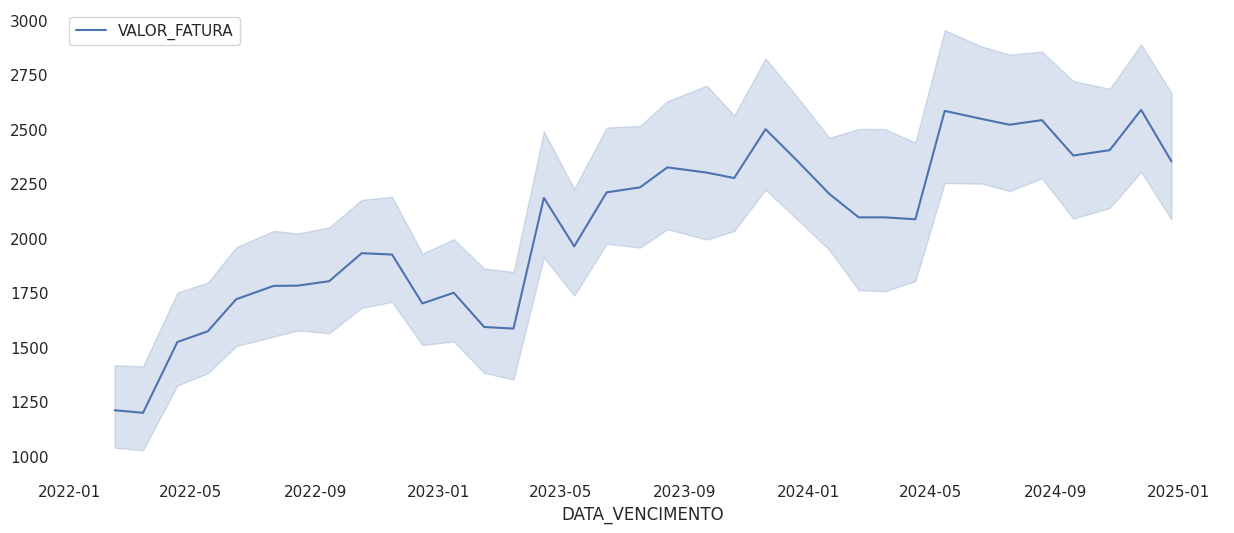

In [4]:
sns.lineplot(df);

### Correlograma - Ruído Branco
Gráfico de autocorrelação (ACF)

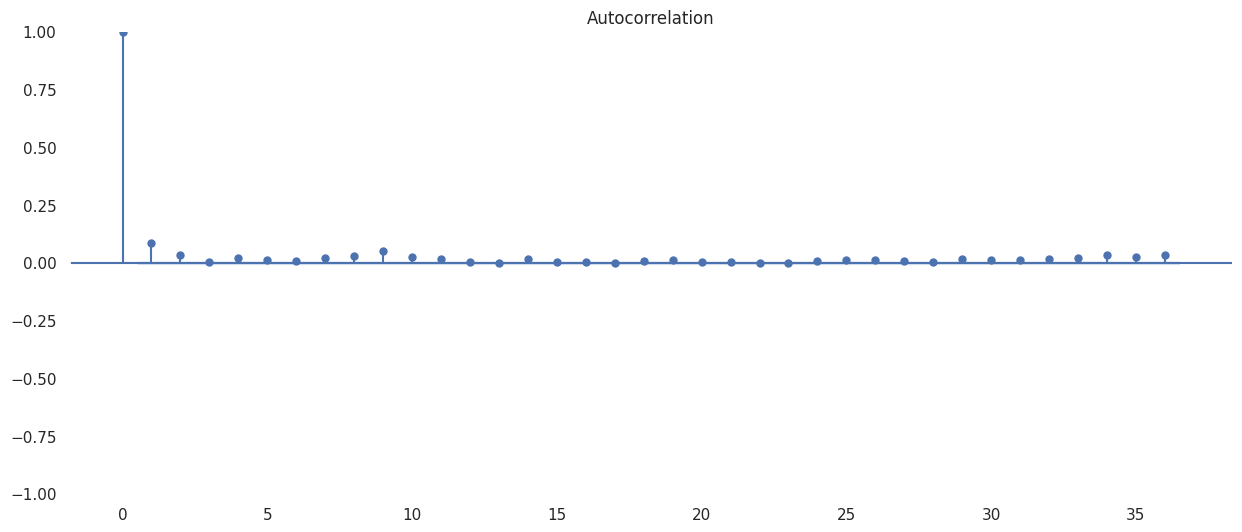

In [4]:
plot_acf(df, lags=36);

### Teste de Estacionaridade

***Teste de Dickey-Fuller Aumentado (ADF)*** O teste de Dickey-Fuller
Aumentado (ADF) é um teste de hipótese usado para verificar a
estacionaridade de uma série temporal.

-   **Hipótese Nula (H0)**: A série temporal tem uma raiz unitária (não
    estacionária).

-   **Hipótese Alternativa (H1)**: A série temporal é estacionária (sem
    raiz unitária).

-   **Rejeitar H0 (valor** $p$ \< 0.05): A série é estacionária.

-   **Não rejeitar H0 (valor** $p$ \> 0.05): A série não é estacionária
    (tem raiz unitária).

In [5]:
adf_result = adfuller(df, autolag='AIC')
print('ADF Test: Ruído Branco')
print('Estatística do teste: {:.4f}'.format(adf_result[0]))
print('p-valor: {:.4f}'.format(adf_result[1]))
print('Valores Críticos:')
for chave, valor in adf_result[4].items():
    print('{}: {:.4f}'.format(chave, valor))
print('Resultado:')
if adf_result[1] <= 0.05:
    print("Rejeitar a hipótese nula (H0): Os dados são estacionários.")
else:
    print("Falha ao rejeitar a hipótese nula (H0): Os dados não são estacionários.")
print('\n')

ADF Test: Ruído Branco
Estatística do teste: -26.9151
p-valor: 0.0000
Valores Críticos:
1%: -3.4304
5%: -2.8616
10%: -2.5668
Resultado:
Rejeitar a hipótese nula (H0): Os dados são estacionários.




#### Teste KPSS (Kwiatkowski-Phillips-Schmidt-Shin)

O teste KPSS é usado para verificar a estacionaridade de uma série
temporal, mas ao contrário do teste ADF, sua hipótese nula é que a série
é estacionária.

##### Hipóteses:

-   **Hipótese Nula (H0)**: A série temporal é estacionária.

-   **Hipótese Alternativa (H1)**: A série temporal não é estacionária.

-   **Rejeitar H0 (valor KPSS grande )**: A série não é estacionária.

-   **Não rejeitar H0 (valor KPSS pequeno)**: A série é estacionária.

In [7]:
kpss_result = kpss(df, regression='c')
print('KPSS Test: Ruído Branco')
print('Estatística do teste: {:.4f}'.format(kpss_result[0]))
print('p-valor: {:.4f}'.format(kpss_result[1]))
print('Valores Críticos:')
for chave, valor in kpss_result[3].items():
    print('{}: {:.4f}'.format(chave, valor))
print('Resultado:')
if kpss_result[1] <= 0.05:
    print("Rejeitar a hipótese nula (H0): Os dados não são estacionários.")
else:
    print("Falha ao rejeitar a hipótese nula (H0): Os dados são estacionários.")
print('\n')

KPSS Test: Ruído Branco
Estatística do teste: 9.2640
p-valor: 0.0100
Valores Críticos:
10%: 0.3470
5%: 0.4630
2.5%: 0.5740
1%: 0.7390
Resultado:
Rejeitar a hipótese nula (H0): Os dados não são estacionários.




/tmp/ipykernel_33419/2574401071.py:1: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(df, regression='c')


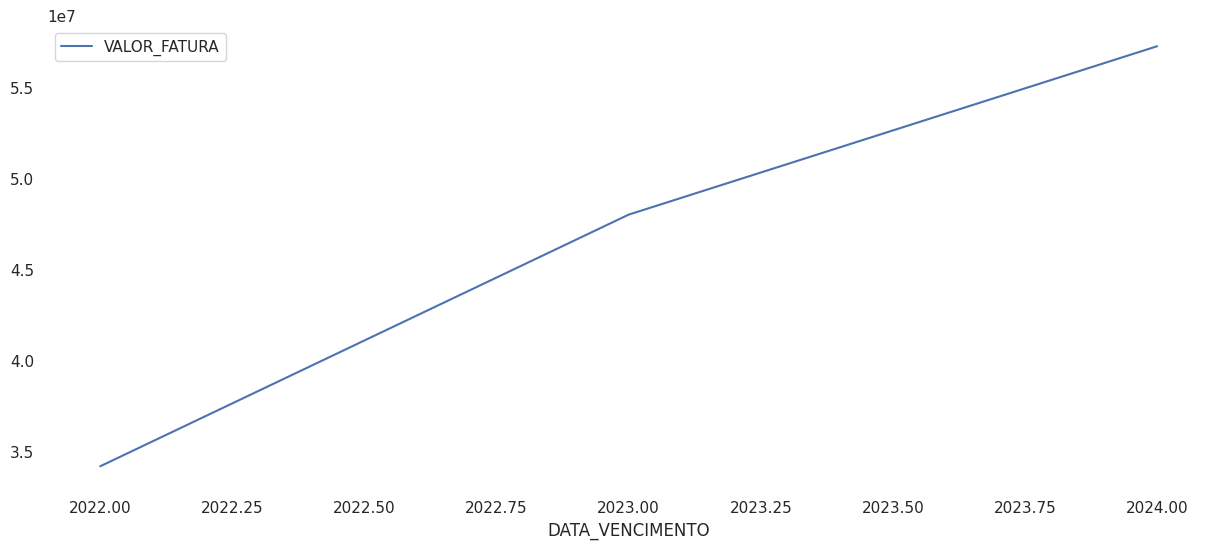

In [10]:
# #
###
# #

# Eliminação do ruído para análise de tendência

e_ruido= df.groupby(df.index.year).sum()
sns.lineplot(e_ruido);

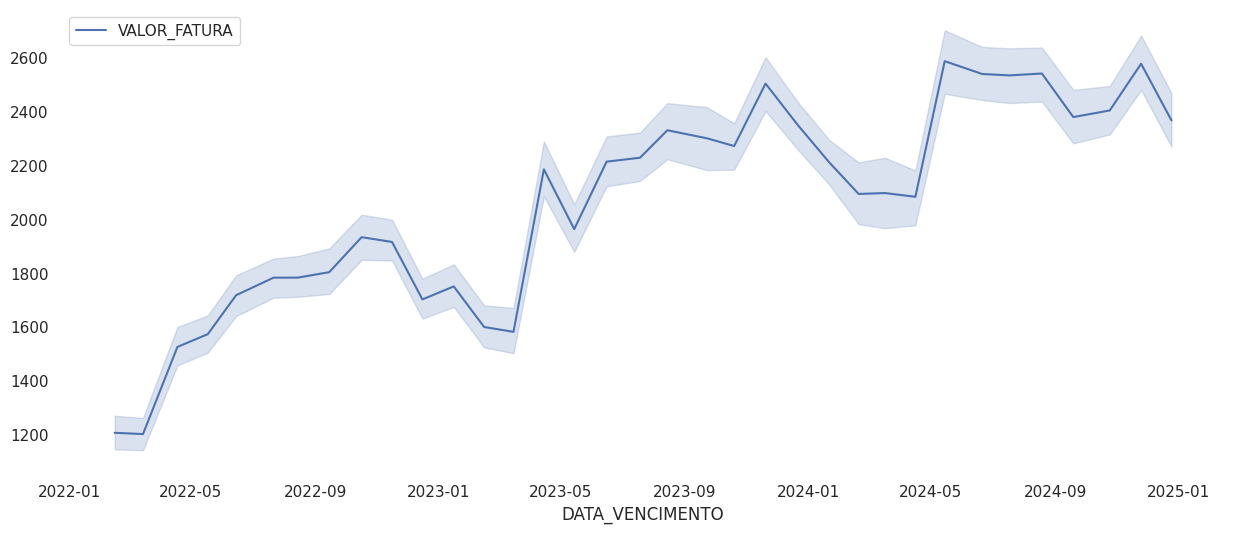

In [9]:
# Eliminação do ruído com média movel simples para análise de tendência

media_movel= df.rolling(12).mean()
sns.lineplot(media_movel);

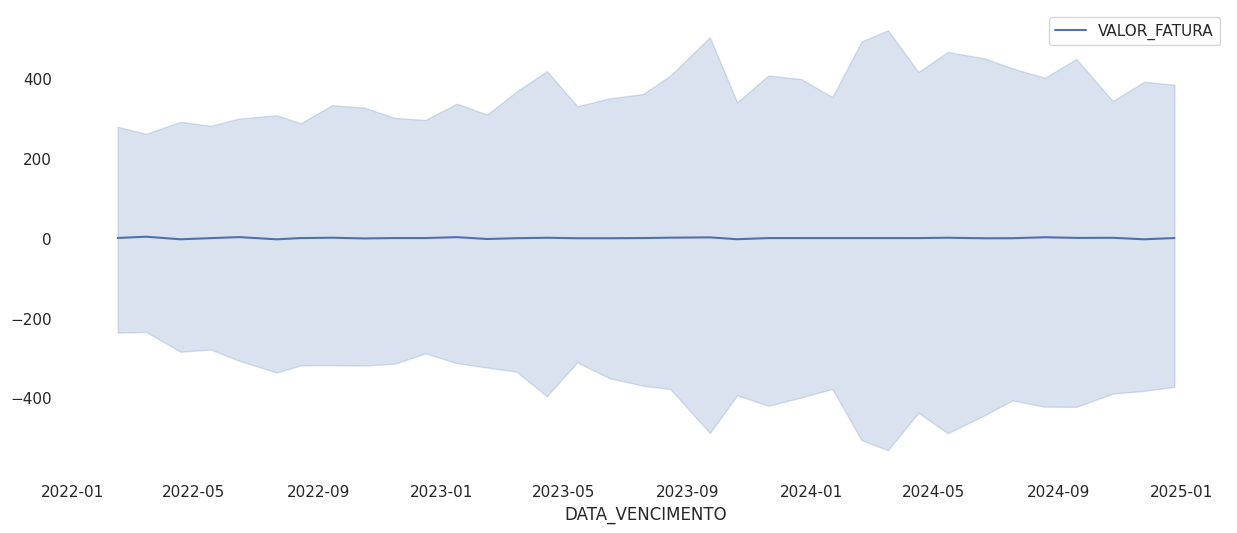

In [8]:
diferenca= df.diff(1)
sns.lineplot(diferenca);

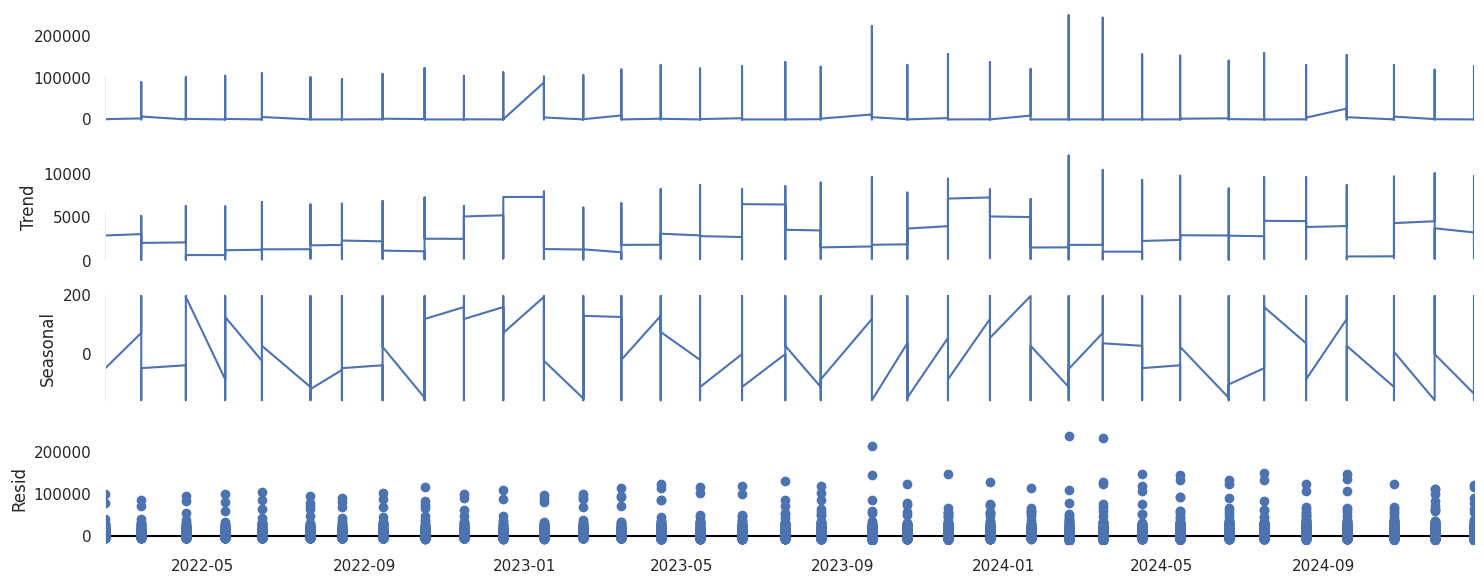

In [11]:
#### Decomposição com `seasonal_decompose` (modelo aditivo)
from statsmodels.tsa.seasonal import seasonal_decompose

decomposicao = seasonal_decompose(df, model="additive", period=30)
decomposicao.plot();